### Artificial Neural Networking using PyTorch

- Dataset: Fashion MNIST from Kaggle
  - 70,000 Training data
  - Grayscale
  - Each has dimension of 28 \* 28

#### Process

We will use CPU to train the model with this dataset. It will be quite heavy for the CPU to make it done. So we will extract 6000 data from the dataset for the time being


#### Architectural Overview

Input Layer:

- Total number of features - 784
- Hidden layers:
  - Layer 1:
    - Number of Nodes: 128
    - Activation Function: ReLU
  - Layer 2:
    - Number of nodes: 64
    - Activation Function: ReLU
- Output Layer:
  - Number of nodes: 10
  - Activation function: SoftMax (As we are dealing with multiclass classification problem)

#### Workflow

- Creating DataLoader Objects
- Training Loop
- Evaluation


In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt


In [10]:
torch.manual_seed(42)

In [13]:
# Check for GPU
# For apple silicon chip, use mps, otherwise use cuda (google colab)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [14]:
df = pd.read_csv('dataset/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


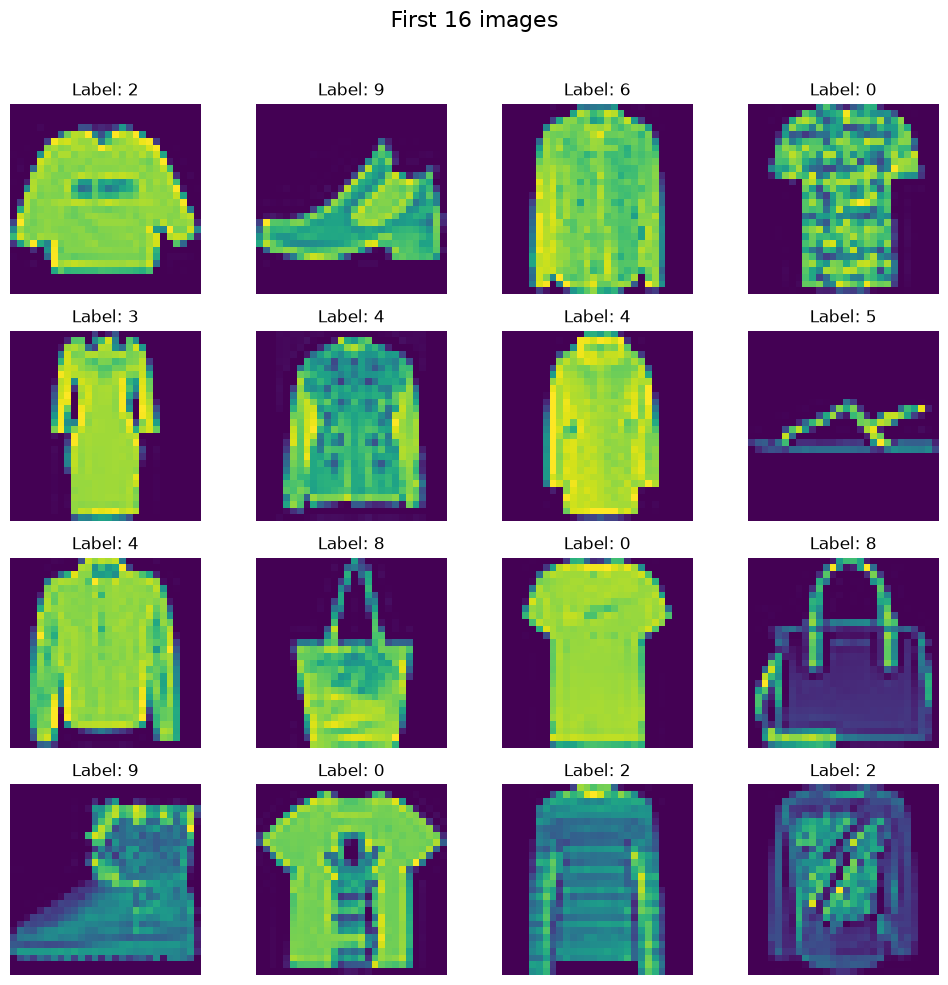

In [15]:
# Create 4x4 (16 images) grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)

# plot the first 16 images from the dataset
for i, ax, in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28) # reshape to 28*28
  ax.imshow(img) # display in grayscale
  ax.axis('off') # remove axis for cleaner look
  ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label
  
plt.tight_layout(rect=[0, 0, 1, 0.96]) # adjust layout to fit the title
plt.show()

In [16]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# scaling the features
# in the dataset, the pixel values are within 0 to 255. 
# It is better for neural networking to make the traning values
# between 0 to 1. That's why diving all by 255.
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
# Create CustomDataset Class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
    
  def __len__(self):
    return len(self.features)
  
  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [21]:
# Create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [23]:
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
# Create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
# Define NN class
# Do not need to add Softmax for output layer
# In pytoch it is added by default
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.ReLU(),
      nn.Linear(128, 64),
      nn.ReLU(),
      nn.Linear(64, 10)
    )
    
  def forward(self, x):
    return self.model(x)

In [26]:
epochs = 100
learning_rate = 0.1

In [27]:
# Instantiate the model
model = MyNN(X_train.shape[1])

# Run the model in GPU
model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)



In [28]:
# Training Loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    
    # forward pass
    outputs = model(batch_features)
    
    # calculate loss
    loss = criterion(outputs, batch_labels)
    
    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # gradients update
    optimizer.step()
    
    total_epoch_loss = total_epoch_loss + loss.item()
  
  avg_loss = total_epoch_loss / len(train_loader)
  print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")
    

Epoch: 1, Loss: 0.6352692385911941
Epoch: 2, Loss: 0.43003414149582386
Epoch: 3, Loss: 0.3858709690098961
Epoch: 4, Loss: 0.3583725085010131
Epoch: 5, Loss: 0.3376641030833125
Epoch: 6, Loss: 0.3221902217591802
Epoch: 7, Loss: 0.30756560811648764
Epoch: 8, Loss: 0.29611334375540416
Epoch: 9, Loss: 0.2855041981637478
Epoch: 10, Loss: 0.2726636084591349
Epoch: 11, Loss: 0.26835035102814436
Epoch: 12, Loss: 0.25898618865509826
Epoch: 13, Loss: 0.2508434251323342
Epoch: 14, Loss: 0.24267052692857882
Epoch: 15, Loss: 0.23728725463648637
Epoch: 16, Loss: 0.2319722787750264
Epoch: 17, Loss: 0.22456941674277187
Epoch: 18, Loss: 0.21967852419738967
Epoch: 19, Loss: 0.2138062867851307
Epoch: 20, Loss: 0.2113377228093644
Epoch: 21, Loss: 0.20560202448566756
Epoch: 22, Loss: 0.19955229680861036
Epoch: 23, Loss: 0.19582781234383584
Epoch: 24, Loss: 0.19087340498281022
Epoch: 25, Loss: 0.18813317300503452
Epoch: 26, Loss: 0.18244366780109703
Epoch: 27, Loss: 0.18042254610545932
Epoch: 28, Loss: 0.17

In [29]:
# Set model to eval mode
# this function turns the model into evaluation mode. 
model.eval()
# it prevents the model from dropping off the neurons which sometimes happens in training over a dataset. 

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [30]:
# evaluation code
# will use test dataset for evaluation the model
total = 0
correct = 0

with torch.no_grad(): # as we do not need gradient while predicting 
  for batch_features, batch_labels in test_loader:
    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    print(f"Outputs: {outputs}")
    _, predicted = torch.max(outputs, 1)
    print(f"Predicted: {predicted}")
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
  
print(correct / total)

Outputs: tensor([[-1.7590e+01,  4.8353e+00, -9.1530e+00, -1.1603e+01,  1.6658e+00,
          4.2304e+00, -1.4473e+01,  3.1198e+01,  2.8582e+00,  9.9859e+00],
        [-2.6805e+00, -2.0990e+01, -1.2153e+01, -1.2620e+01,  8.2289e+00,
         -1.0839e+01,  5.5868e+00, -4.8311e+00,  5.1558e+01, -5.5966e-01],
        [ 6.0807e-01, -1.1758e+01, -1.4022e+01, -1.6919e+01,  6.3668e+00,
         -7.9104e+00, -5.6261e-01, -1.1488e+01,  4.9374e+01,  4.7448e+00],
        [-9.4831e+00,  6.3723e+00, -1.9301e+00, -8.9281e+00, -4.7115e+00,
          1.8940e+01,  4.2735e-01,  1.5681e-02, -1.7293e+01,  8.1139e+00],
        [-7.5495e+00,  1.9840e+00, -1.4488e+01, -1.2840e+01, -6.9064e+00,
         -5.5433e+00, -1.0843e+01,  1.5347e+01, -1.4157e+01,  4.3454e+01],
        [ 3.5847e+00,  3.5984e+01,  5.2944e+00,  1.1572e+01, -6.1142e+00,
         -7.5777e+00, -1.1398e+01, -1.9657e+01, -1.1539e+00, -9.1906e+00],
        [ 3.0890e-01, -3.9513e+00,  2.2012e+01, -6.8365e+00,  9.0872e+00,
         -4.1216e+00,  